## 餐厅订单分析

#### 1.订单表长度
#### 2.统计菜名的平均价格
#### 3.什么菜最受欢迎
#### 4.点菜最多的ID


In [1]:
!pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple --trusted-host pypi.tuna.tsinghua.edu.cn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [2]:
# 安装 pandas 读取 xlsx excel 文件必须要的包
!python -m pip install openpyxl -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
plt.rcParams['font.sans-serif'] = 'SimHei' ## 设置中文显示
# 1.加载数据
xx = "C:\\Users\\63546\\Desktop\\餐厅\\数据分析实战项目资料\\1、餐厅订单数据分析\\1-认识数据并预处理\\资料\\meal_order_detail.xlsx"
data1 = pd.read_excel( xx , sheet_name='meal_order_detail1')
data2 = pd.read_excel( xx , sheet_name='meal_order_detail2')
data3 = pd.read_excel( xx , sheet_name='meal_order_detail3')

In [5]:
data1.head()

,detail_id,order_id,dishes_id,logicprn_name,parent_class_name,dishes_name,itemis_add,counts,amounts,cost,place_order_time,discount_amt,discount_reason,kick_back,add_inprice,add_info,bar_code,picture_file,emp_id
0,2956,417,610062,NaN,NaN,蒜蓉生蚝,0,1,49,NaN,2016-08-01 11:05:36,NaN,NaN,NaN,0,NaN,NaN,caipu/104001.jpg,1442
1,2958,417,609957,NaN,NaN,蒙古烤羊腿,0,1,48,NaN,2016-08-01 11:07:07,NaN,NaN,NaN,0,NaN,NaN,caipu/202003.jpg,1442
2,2961,417,609950,NaN,NaN,大蒜苋菜,0,1,30,NaN,2016-08-01 11:07:40,NaN,NaN,NaN,0,NaN,NaN,caipu/303001.jpg,1442
3,2966,417,610038,NaN,NaN,芝麻烤紫菜,0,1,25,NaN,2016-08-01 11:11:11,NaN,NaN,NaN,0,NaN,NaN,caipu/105002.jpg,1442
4,2968,417,610003,NaN,NaN,蒜香包,0,1,13,NaN,2016-08-01 11:11:30,NaN,NaN,NaN,0,NaN,NaN,caipu/503002.jpg,1442


In [6]:
# 2.数据预处理（合并数据,NA等处理），分析数据
data = pd.concat([data1,data2,data3],axis=0)  #按照行进行拼接数据
data.dropna(axis=1,inplace=True) #按照列删除na列，并且修改源数据
data.info() #打印基础信息概况，包括：总行数、所有列名、每一列非空数据数量、数据类型

<class 'pandas.DataFrame'>
Index: 10037 entries, 0 to 3610
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   detail_id         10037 non-null  int64         
 1   order_id          10037 non-null  int64         
 2   dishes_id         10037 non-null  int64         
 3   dishes_name       10037 non-null  str           
 4   itemis_add        10037 non-null  int64         
 5   counts            10037 non-null  int64         
 6   amounts           10037 non-null  int64         
 7   place_order_time  10037 non-null  datetime64[us]
 8   add_inprice       10037 non-null  int64         
 9   picture_file      10037 non-null  str           
 10  emp_id            10037 non-null  int64         
dtypes: datetime64[us](1), int64(8), str(2)
memory usage: 941.0 KB


In [7]:
# 3.统计卖出菜品的平均价格
a = round(data['amounts'].mean(),2)  #方法一：pandas自带函数
b = round(np.mean(data['amounts']),2)  #方法二：numpy函数处理
print(a,b)

44.82 44.82


In [8]:
# 4.频数统计，什么菜最受欢迎  （对菜名进行频数统计，取最大前10名）
dishes_count = data['dishes_name'].value_counts()[:10]
print(dishes_count)

dishes_name
白饭/大碗        323
凉拌菠菜         269
谷稻小庄         239
麻辣小龙虾        216
辣炒鱿鱼         189
芝士烩波士顿龙虾     188
五色糯米饭(七色)    187
白饭/小碗        186
香酥两吃大虾       178
焖猪手          173
Name: count, dtype: int64


0 323
1 269
2 239
3 216
4 189
5 188
6 187
7 186
8 178
9 173


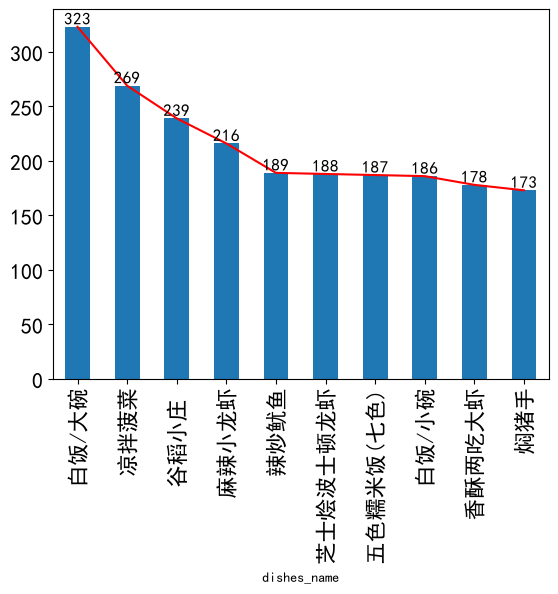

In [9]:
# 5.数据可视化matplotlib
dishes_count.plot(kind='line',color='r') # 绘制线形图
dishes_count.plot(kind='bar',fontsize=16) # 绘制柱形图，fontsize为文字字号
for x in range(len(dishes_count)):
    y = dishes_count.values[x] 
    print(x,y) # 同时取出索引x和数值y(点单次数)
    plt.text(x,y+2,y,ha='center',fontsize=12) # 在每个柱上方添加数字标签，y+2为文字纵坐标，让文字往上移一点，避免贴在柱子顶端，y为要显示的文本内容

Text(0, 0.5, '点菜种类')

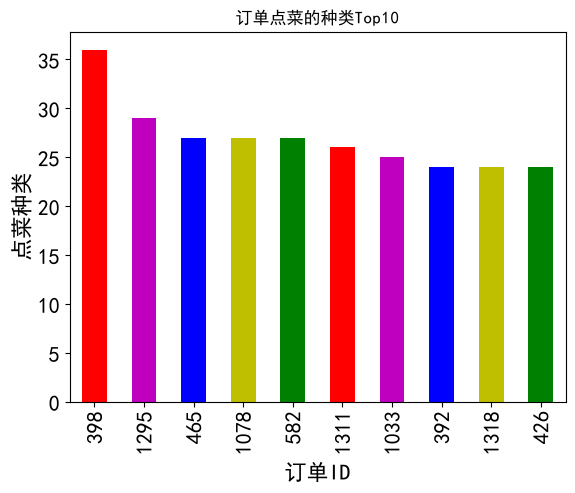

In [10]:
# 6.订单点菜种类最多的ID（1，1，1    1，2，3）
data_group = data['order_id'].value_counts()[:10] # 先选取订单ID列，再统计每个ID出现的次数，最后取出出现次数最多的10个
data_group.plot(kind='bar',fontsize=16,color=['r','m','b','y','g'])
plt.title('订单点菜的种类Top10')
plt.xlabel('订单ID',fontsize=16)
plt.ylabel('点菜种类',fontsize=16)

Text(0.5, 1.0, '订单ID点菜数量Top10')

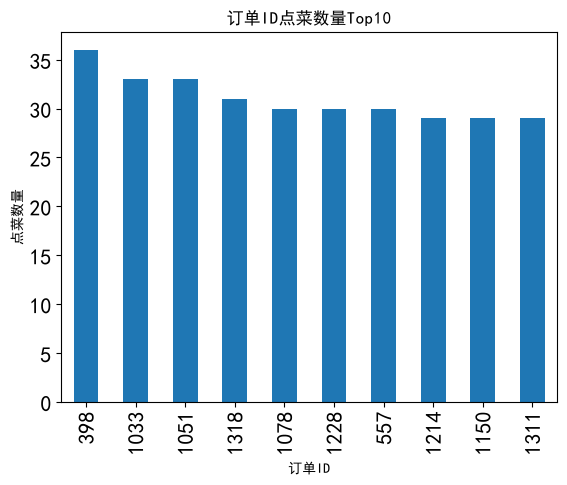

In [11]:
# 7.订单ID点菜数量Top10（分组order_id,counts求和，排序，前十）
data['total_amounts'] =data['counts']*data['amounts']  #统计单道菜消费总额
dataGroup = data[['order_id','counts','amounts','total_amounts']].groupby(by='order_id') #按照ID分组
Group_sum = dataGroup.sum()  #分组求和
#print(Group_sum )
sort_counts = Group_sum.sort_values(by='counts',ascending=False) #按照ID排序(降序)
sort_counts['counts'][:10].plot(kind='bar',fontsize=16)
plt.xlabel('订单ID')
plt.ylabel('点菜数量')
plt.title('订单ID点菜数量Top10')

Text(0.5, 1.0, '消费金额前10')

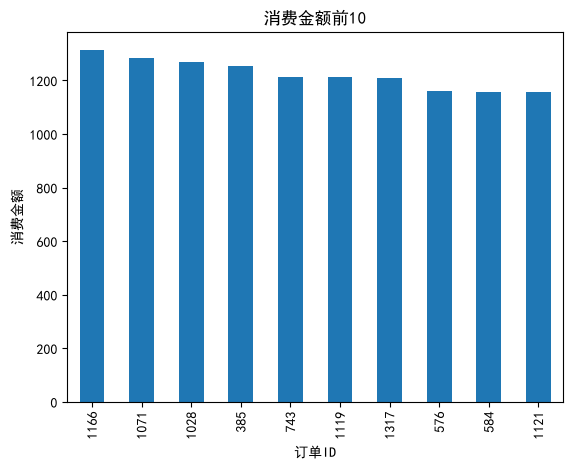

In [12]:
# 8.哪个订单ID消费金额最多（排序）
sort_total_amounts = Group_sum.sort_values(by='total_amounts',ascending=False)
sort_total_amounts['total_amounts'][:10].plot(kind='bar')
plt.xlabel('订单ID')
plt.ylabel('消费金额')
plt.title('消费金额前10')

Text(0.5, 1.0, '点菜数与小时的关系图')

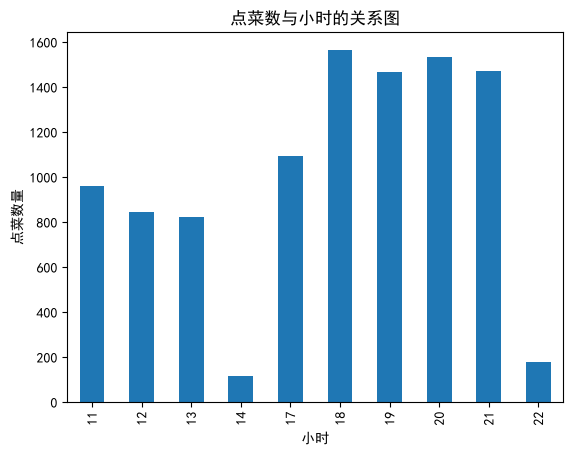

In [13]:
# 9.一天当中什么时间段，点菜量比较集中（hour）
data['hourcount'] = 1 # 新列，用作计数器
data['time'] = pd.to_datetime(data['place_order_time']) #将时间转换成日期类型存储
data['hour'] = data['time'].map(lambda x:x.hour)
gp_by_hour = data.groupby(by='hour').count()['hourcount']
gp_by_hour.plot(kind='bar')
plt.xlabel('小时')
plt.ylabel('点菜数量')
plt.title('点菜数与小时的关系图')